# AML s26 - Tree-Based Regression Models Comparison

Goal: compares three tree-based regression techniques:
- a) **Decision Tree Regressor** - Single tree model
- b) **Random Forest Regressor** - Ensemble of trees 
- c) **Gradient Boosting Regressor** - Sequential ensemble with boosting

### Load libraries 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error

from sklearn.model_selection import cross_val_score
import pandas as pd
import time


### Generate Synthetic Data

We create a 1D dataset where the true function is `sin(x)` with added noise.

In [2]:
rng = np.random.RandomState(0)
X = np.sort(5 * rng.rand(80, 1), axis=0)  # inputs in [0, 5]
y = np.sin(X).ravel()                      # true function
y += 0.1 * rng.randn(X.shape[0])           # add noise

# Create a dense grid for visualization and testing
X_test = np.linspace(0, 5, 500).reshape(-1, 1)
y_true = np.sin(X_test).ravel() 

print(f"Training samples: {X.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Input range: [{X.min():.2f}, {X.max():.2f}]")

Training samples: 80
Test samples: 500
Input range: [0.09, 4.94]


### Define and Train Models

In [3]:
# define random state
rs = 0

# Define models 
models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=rs),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=5, random_state=rs),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=rs)
}

# Train models and store predictions
predictions = {}
train_times = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X, y)
    train_times[name] = time.time() - start_time
    predictions[name] = model.predict(X_test)
    print(f"{name}: trained in {train_times[name]:.4f} seconds")

Decision Tree: trained in 0.0052 seconds
Random Forest: trained in 0.2455 seconds
Gradient Boosting: trained in 0.1954 seconds


### Visualize Individual Models 

a) Decision Tree Regressor

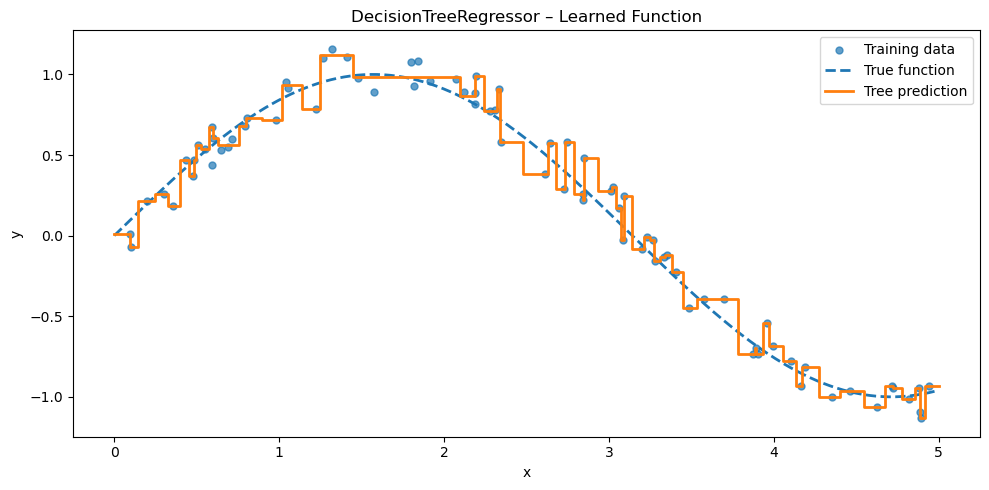

In [4]:
plt.figure(figsize=(10, 5))
plt.scatter(X, y, s=25, label="Training data", alpha=0.7)
plt.plot(X_test, y_true, "--", linewidth=2, label="True function")
plt.step(X_test.ravel(), predictions["Decision Tree"], where="mid",  linewidth=2, label="Tree prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("DecisionTreeRegressor – Learned Function")
plt.legend()
plt.tight_layout()
plt.show()

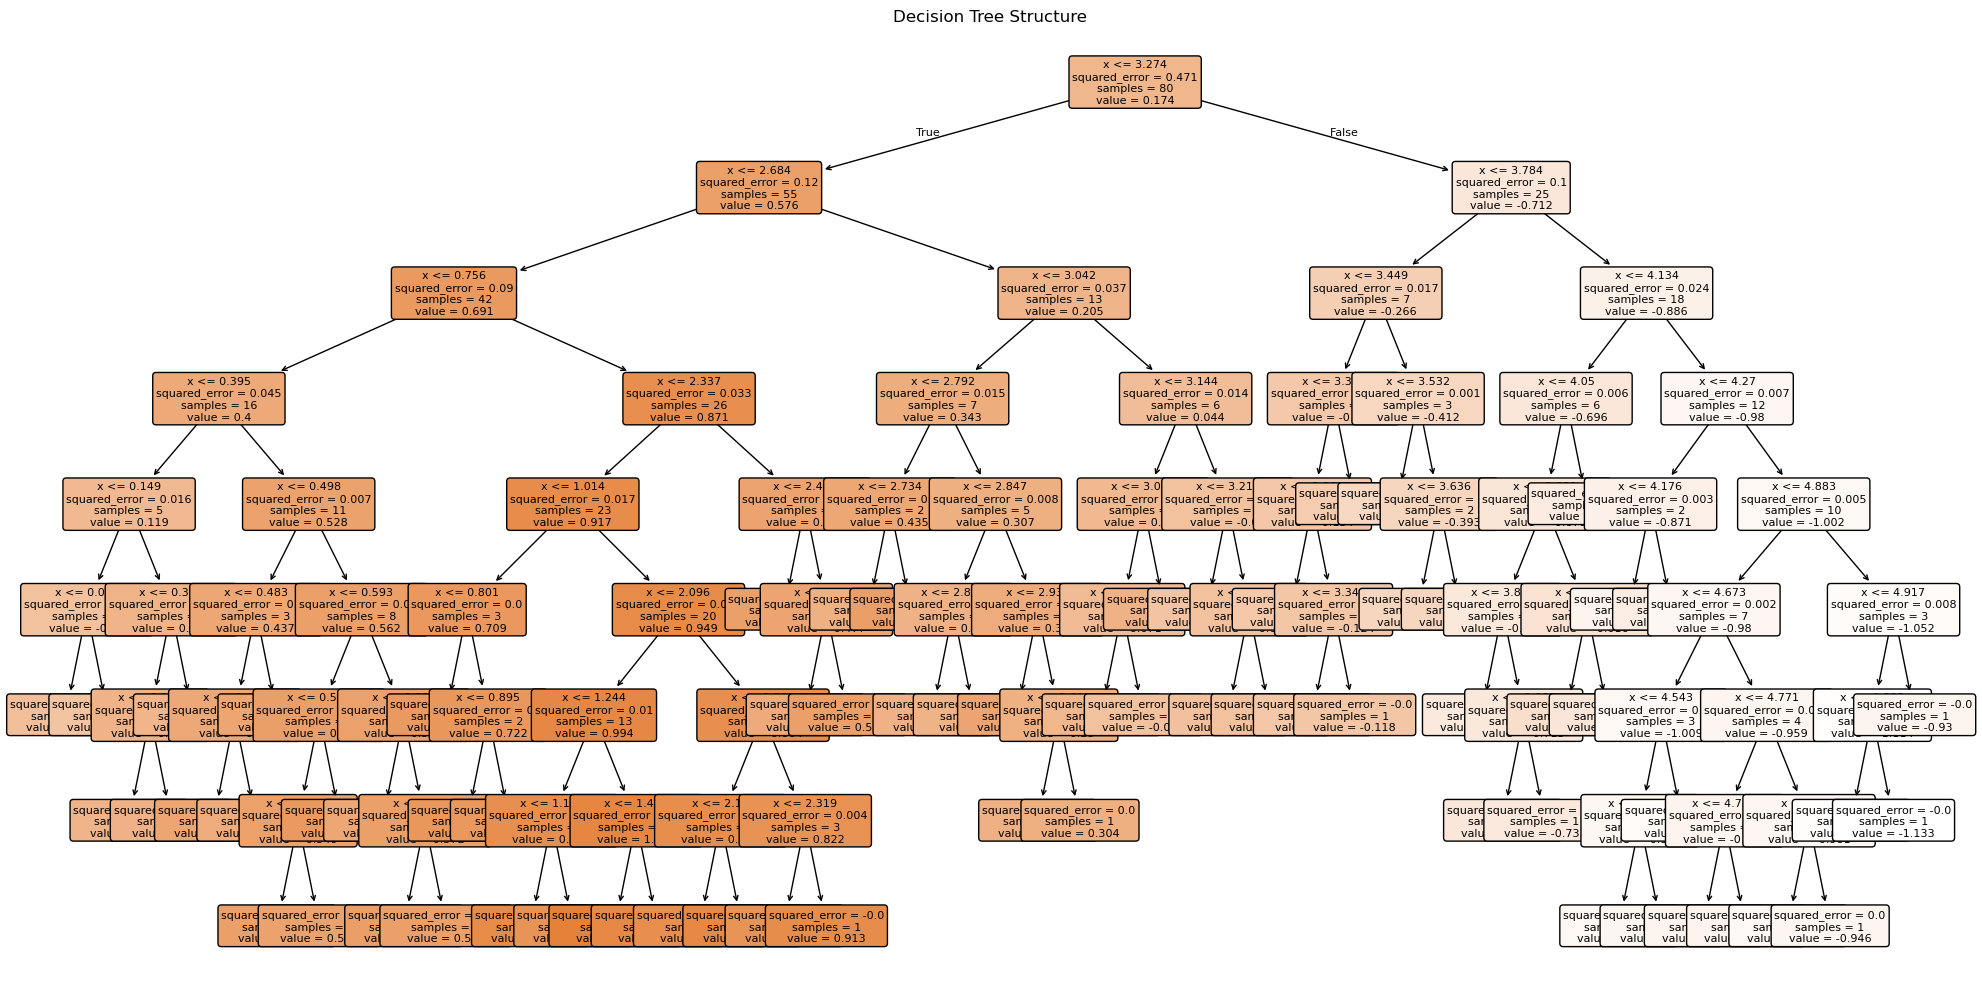

In [5]:
# Visualize tree structure
plt.figure(figsize=(20, 10))
plot_tree(models["Decision Tree"], filled=True, feature_names=["x"],  rounded=True, fontsize=8)
plt.title("Decision Tree Structure")
plt.tight_layout()
plt.show()

b) Random Forest Regressor

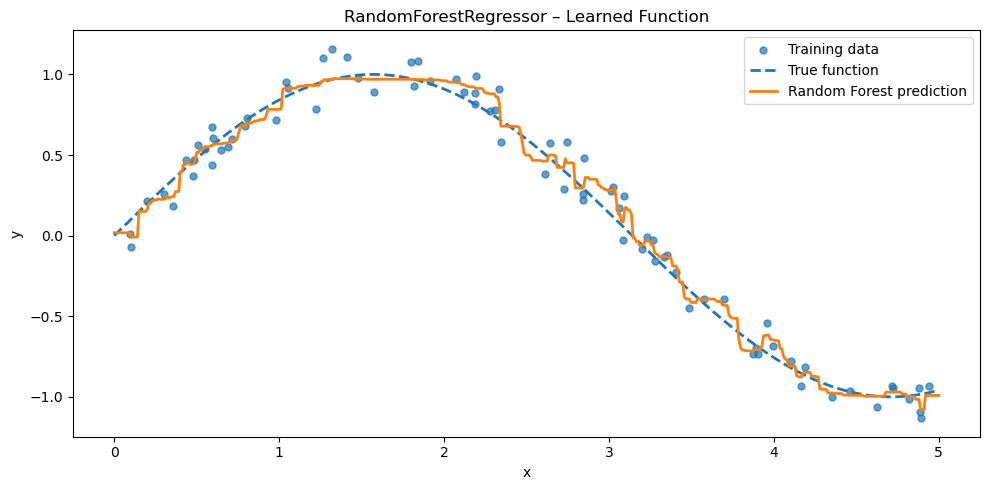

In [6]:
plt.figure(figsize=(10, 5))
plt.scatter(X, y, s=25, label="Training data", alpha=0.7)
plt.plot(X_test, y_true, "--", linewidth=2, label="True function")
plt.plot(X_test, predictions["Random Forest"], linewidth=2, label="Random Forest prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("RandomForestRegressor – Learned Function")
plt.legend()
plt.tight_layout()
plt.show()

c) Gradient Boosting Regressor

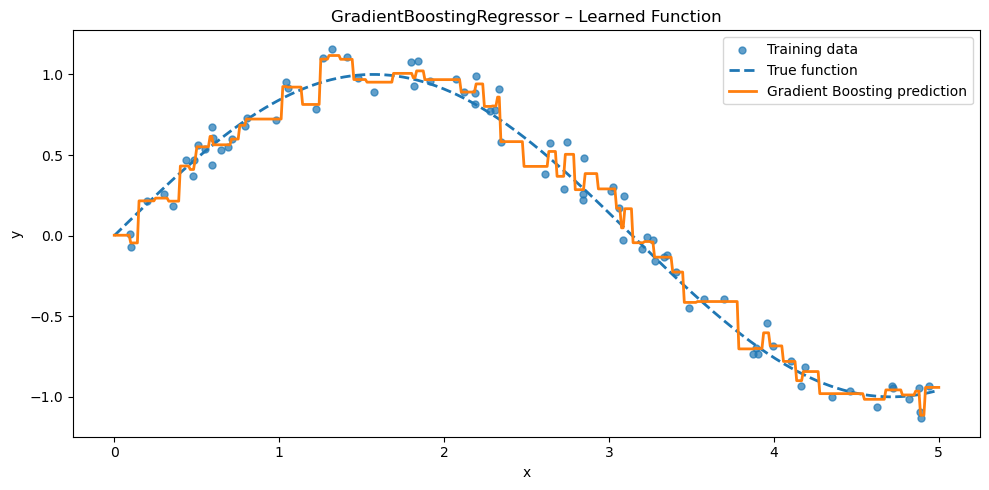

In [7]:
plt.figure(figsize=(10, 5))
plt.scatter(X, y, s=25, label="Training data", alpha=0.7)
plt.plot(X_test, y_true, "--", linewidth=2, label="True function")
plt.plot(X_test, predictions["Gradient Boosting"],  linewidth=2,   label="Gradient Boosting prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("GradientBoostingRegressor – Learned Function")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Combined Comparison Plot

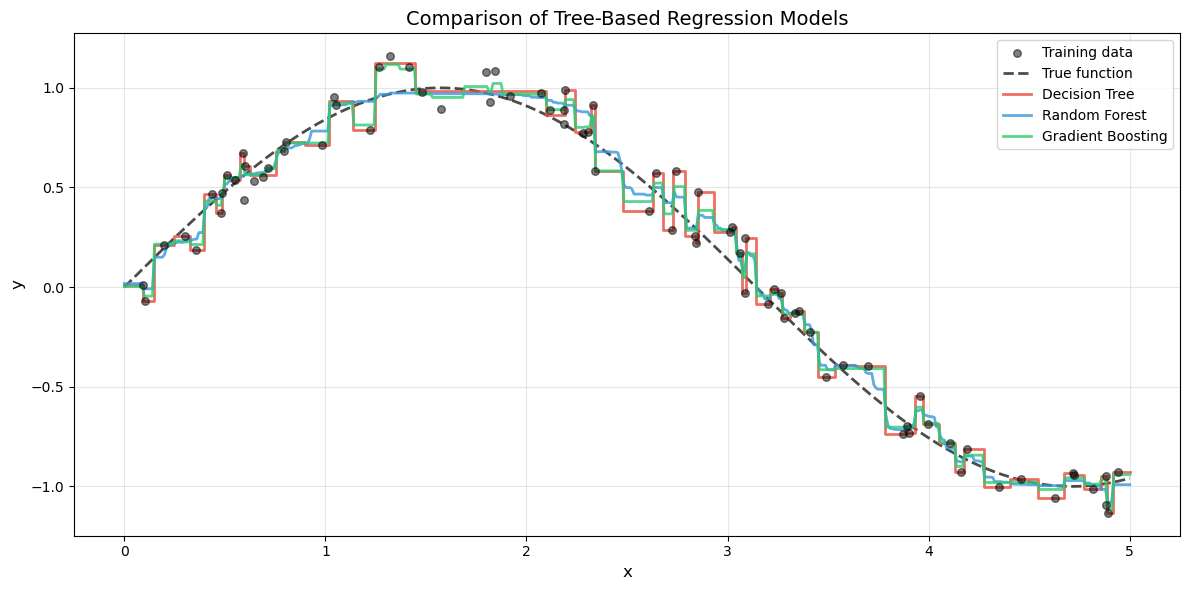

In [8]:
plt.figure(figsize=(12, 6))

# Plot training data and true function
plt.scatter(X, y, s=30, c='black', alpha=0.5, label="Training data", zorder=5)
plt.plot(X_test, y_true, 'k--', linewidth=2, label="True function", alpha=0.7)

# Plot all model predictions
colors = ['#e74c3c', '#3498db', '#2ecc71']
for (name, pred), color in zip(predictions.items(), colors):
    if name == "Decision Tree":
        plt.step(X_test.ravel(), pred, where="mid", linewidth=2,  label=name, color=color, alpha=0.8)
    else:
        plt.plot(X_test, pred, linewidth=2, label=name, color=color, alpha=0.8)

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("Comparison of Tree-Based Regression Models", fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Performance Comparison Metrics

In [9]:
def calculate_metrics(y_true, y_pred, y_train, y_train_pred):
    """Calculate comprehensive regression metrics."""
    return {
        'R² (test)': r2_score(y_true, y_pred),
        'R² (train)': r2_score(y_train, y_train_pred),
    }

# Calculate metrics for each model
metrics_results = {}
for name, model in models.items():
    y_pred_test = predictions[name]
    y_pred_train = model.predict(X)
    metrics_results[name] = calculate_metrics(y_true, y_pred_test, y, y_pred_train)
    metrics_results[name]['Training Time (s)'] = train_times[name]

# Create comparison DataFrame
metrics_df = pd.DataFrame(metrics_results).T
metrics_df = metrics_df.round(6)
print("Performance Metrics Comparison")
print("=" * 80)
metrics_df

Performance Metrics Comparison


,R² (test),R² (train),Training Time (s)
Decision Tree,0.980339,0.998936,0.005171
Random Forest,0.993087,0.989995,0.245461
Gradient Boosting,0.987767,0.997231,0.195373
